In [11]:
from core.sr_study_analysis import run_analysis, run_selected_configs, ExperimentSpec
from core.sr_sim import StudyType

## Scenarios and parameter grids

In [12]:
from core.dgp import IIDProcess, SkewTInnov, APDInnov
from core.sr_study_analysis import set_extra_dgps

DGP_EXAMPLES: dict[str, callable] = {
    "apd_base": (
        lambda **kwargs: IIDProcess(APDInnov(alpha=0.7, lam=1.35))
    ),
    "apd_pos_skew": (
        lambda lam: IIDProcess(APDInnov(alpha=0.1, lam=lam))
    ),
    "apd_neg_skew": (
        lambda lam: IIDProcess(APDInnov(alpha=0.9, lam=lam))
    ),
}
set_extra_dgps(DGP_EXAMPLES)


In [13]:
# name : (dgp_names, model_short_names)
scenarios = {
    "...": (
        ["apd_base"],
        ["iid_nonnormal"],
    ),
}

parameters = {
    "sr":    [0.5, 1.0, 1.5],
    "T":     [100, 500, 2_000],
    "n_sim": [1_000, 3_000, 10_000],
}

## Experiment registry

Each entry is an `ExperimentSpec`.  
Set `study_type` to one of:
- `StudyType.TWO_SIDED_COVERAGE` / `ONE_SIDED_COVERAGE`  — size / coverage runs  
- `StudyType.TWO_SIDED_POWER`    / `ONE_SIDED_POWER`     — power runs (requires `null_sr`)

In [14]:
N_SIM  = 10_000
N_JOBS = 8

experiments = {
    "table1_a_nadj": ExperimentSpec(
        scenario   = (["apd_base"],["iid_nonnormal"]),
        param_name = "T",
        param_values = [15, 30, 50, 100, 300],
        study_type = StudyType.ONE_SIDED_COVERAGE,
        calib_sigma   = 1.0,
        th_moments = False,
        sr_default = 0.0,
        n_default = N_SIM, n_jobs = N_JOBS,
    ),
    "table1_b_nadj": ExperimentSpec(
        scenario   = (["apd_base"],["iid_nonnormal"]),
        param_name = "T",
        param_values = [15, 30, 50, 100, 300],
        study_type = StudyType.ONE_SIDED_COVERAGE,
        calib_sigma   = 1.0,
        th_moments = False,
        sr_default = 1.0,
        n_default  = N_SIM, n_jobs = N_JOBS,
    ),
    "fig5_b": ExperimentSpec(
        scenario   = (["apd_pos_skew"],["iid_nonnormal"]),
        param_name = "T",
        param_values = [15, 30, 50, 100, 300],
        study_type = StudyType.ONE_SIDED_COVERAGE,
        calib_sigma   = 1.0,
        th_moments = False,
        sr_default = 3.0,
        n_default  = N_SIM, n_jobs = N_JOBS,
        label_param  = "lam",
        label_values = [1.0, 1.25, 1.50, 1.75, 2.0],
    ),
    "fig5_d": ExperimentSpec(
        scenario   = (["apd_neg_skew"],["iid_nonnormal"]),
        param_name = "T",
        param_values = [15, 30, 50, 100, 300],
        study_type = StudyType.ONE_SIDED_COVERAGE,
        calib_sigma   = 1.0,
        th_moments = False,
        sr_default = 3.0,
        n_default  = N_SIM, n_jobs = N_JOBS,
        label_param  = "lam",
        label_values = [1.0, 1.25, 1.50, 1.75, 2.0],
    ),
    "fig6_b": ExperimentSpec(
        scenario   = (["apd_base"],["iid_nonnormal"]),
        param_name = "T",
        param_values = [15, 30, 50, 100, 300],
        study_type = StudyType.ONE_SIDED_COVERAGE,
        calib_sigma   = 1.0,
        th_moments = False,
        sr_default = 1.0,
        n_default  = N_SIM, n_jobs = N_JOBS,
        label_param  = "null_sr",
        label_values = [0.0, 0.2, 1.0, 3.0],
    ),
    "fig7": ExperimentSpec( #pend bias correct
        scenario   = (["apd_base"],["iid_nonnormal"]),
        param_name = "T",
        param_values = [15, 30, 50, 100, 300],
        study_type = StudyType.ONE_SIDED_POWER,
        calib_sigma   = 1.0,
        th_moments = False,
        null_sr = 0.0,
        n_default  = N_SIM, n_jobs = N_JOBS,
        label_param  = "sr",
        label_values = [0.1, 0.2, 0.3, 0.4, 0.5],
    ),
    "fig8_a": ExperimentSpec( #pend bias correct
        scenario   = (["apd_base"],["iid_nonnormal"]),
        param_name = "T",
        param_values = [15, 30, 50, 100, 300],
        study_type = StudyType.ONE_SIDED_POWER,
        calib_sigma   = 1.0,
        th_moments = False,
        n_default  = N_SIM, n_jobs = N_JOBS,
        label_param  = ("null_sr", "sr"),
        label_values = [(0.2,0.4), (1.0,1.5), (3.0,3.5)],
    ),
    "fig8_b": ExperimentSpec( #pend bias correct
        scenario   = (["apd_base"],["iid_nonnormal"]),
        param_name = "T",
        param_values = [15, 30, 50, 100, 300],
        study_type = StudyType.ONE_SIDED_POWER,
        calib_sigma   = 1.0,
        th_moments = False,
        n_default  = N_SIM, n_jobs = N_JOBS,
        label_param  = ("null_sr", "sr"),
        label_values = [(0.0,0.5), (1.0,1.5), (3.0,3.5)],
    ),
}

---
## EXECUTION

In [24]:
# ── coverage / size runs ──────────────────────────────────────────────────────
run_selected_configs(
    experiments,
    selected_experiments=[
        #"table1_a_nadj",
        "table1_b_nadj",
        #"fig5_b",
        #"fig5_d",
        #"fig6_b",
        #"fig7",
        #"fig8_a",
        #"fig8_b",
        #"aux",
    ],
)


  Experiment: table1_b_nadj
  [1/5]  T=15  (ONE_SIDED_COVERAGE)
  [2/5]  T=30  (ONE_SIDED_COVERAGE)
  [3/5]  T=50  (ONE_SIDED_COVERAGE)
  [4/5]  T=100  (ONE_SIDED_COVERAGE)
  [5/5]  T=300  (ONE_SIDED_COVERAGE)


---
## VISUALIZATION — Coverage / Size

In [25]:
#common
line_plot_kargs = dict(reverse=True, 
                       markers = ['D', 's', 'o', 'X', 'v'],
                       palette = ['black'],
                       linewidth=1,
                       yticks=[0.00, 0.05, 0.10, 0.15, 0.20, 0.25])

=== ONE_SIDED_COVERAGE — T sweep ===
  T dgp_name    avar_model  nominal  coverage     bias     rmse
 15 apd_base iid_nonnormal     0.95    0.9302 0.034039 0.292933
 30 apd_base iid_nonnormal     0.95    0.9420 0.016872 0.195276
 50 apd_base iid_nonnormal     0.95    0.9442 0.011563 0.147078
100 apd_base iid_nonnormal     0.95    0.9495 0.004618 0.101247
300 apd_base iid_nonnormal     0.95    0.9539 0.001379 0.057597


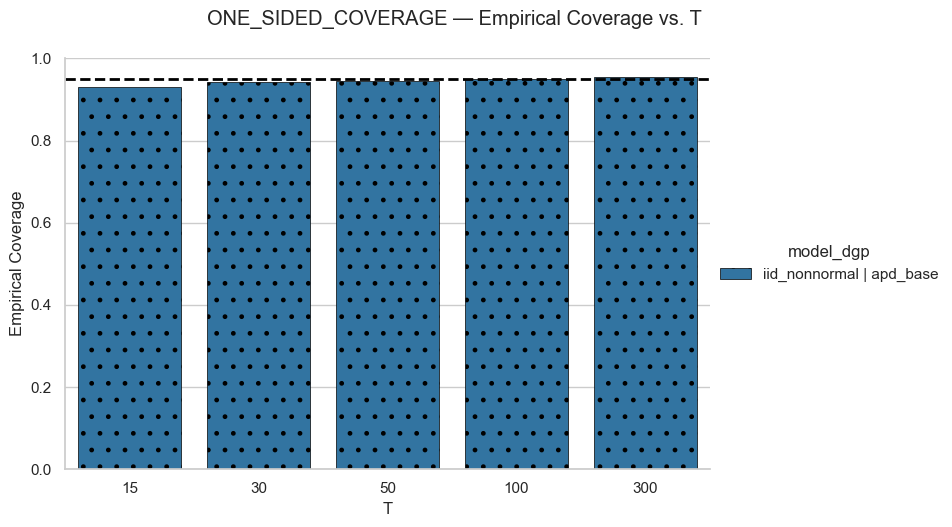

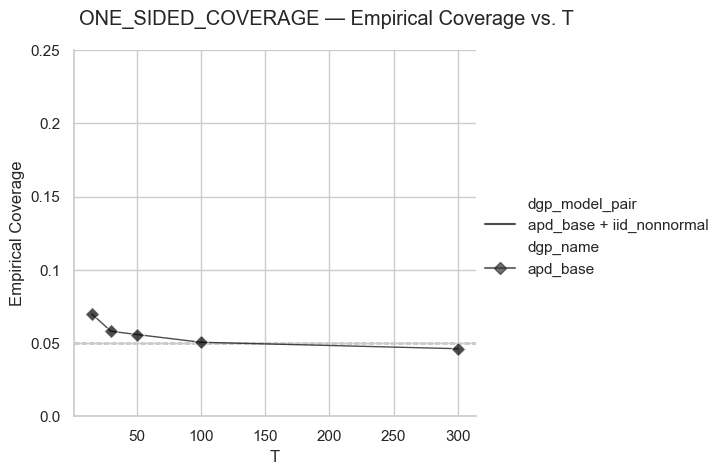

In [26]:
run_analysis(experiments, "table1_a_nadj", alpha=0.05, line_plot_kargs=line_plot_kargs)

=== ONE_SIDED_COVERAGE — T sweep ===
  T dgp_name    avar_model  nominal  coverage     bias     rmse
 15 apd_base iid_nonnormal     0.95    0.8719 0.131159 0.528413
 30 apd_base iid_nonnormal     0.95    0.9035 0.064621 0.339605
 50 apd_base iid_nonnormal     0.95    0.9148 0.039813 0.255556
100 apd_base iid_nonnormal     0.95    0.9312 0.017884 0.176213
300 apd_base iid_nonnormal     0.95    0.9435 0.005828 0.099355


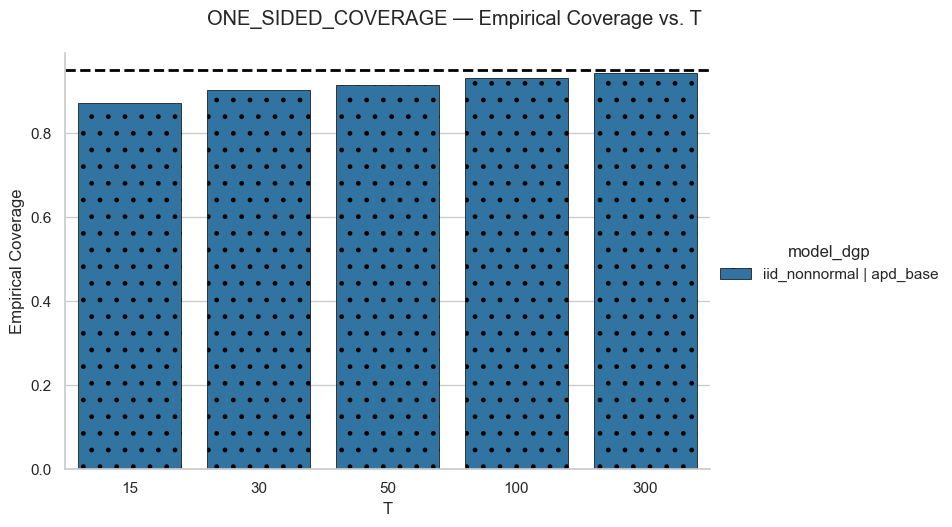

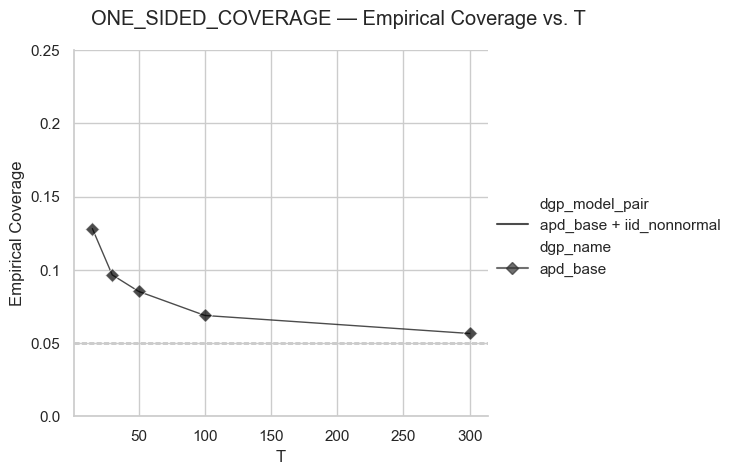

In [27]:
run_analysis(experiments, "table1_b_nadj", alpha=0.05, line_plot_kargs=line_plot_kargs)

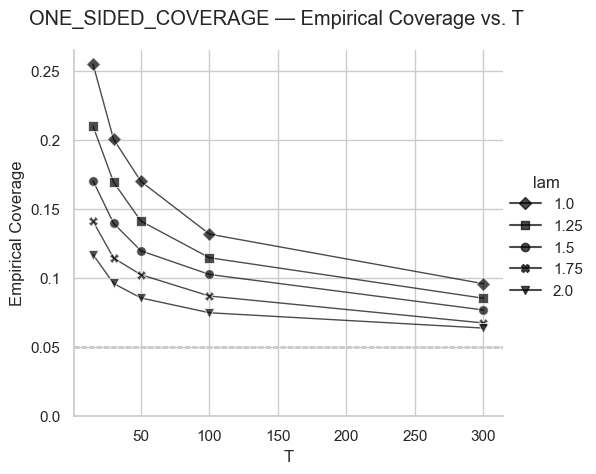

In [28]:
run_analysis(experiments, "fig5_b", alpha=0.05, plot_mask=[0,0,1], 
             line_plot_kargs=line_plot_kargs | {'yticks': [0.00, 0.05, 0.10, 0.15, 0.20, 0.25]})

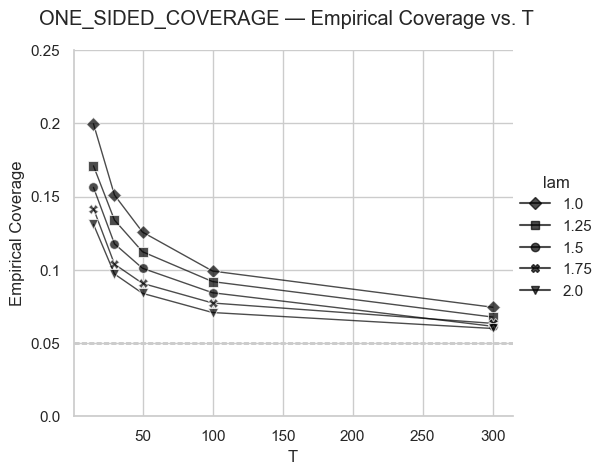

In [29]:
run_analysis(experiments, "fig5_d", alpha=0.05, plot_mask=[0,0,1], 
             line_plot_kargs=line_plot_kargs | {'yticks': [0.00, 0.05, 0.10, 0.15, 0.20, 0.25]})

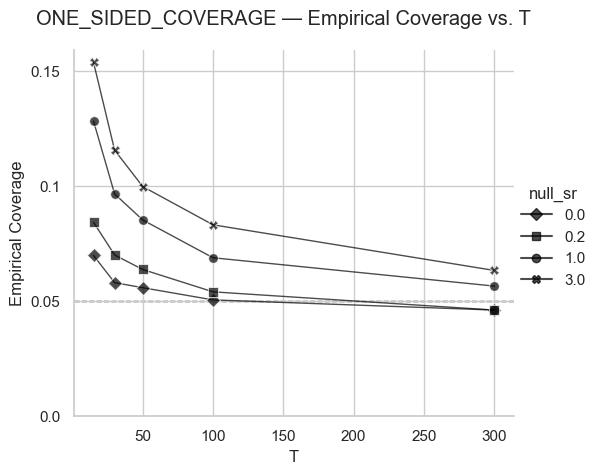

In [30]:
run_analysis(experiments, "fig6_b", alpha=0.05, plot_mask=[0,0,1], 
             line_plot_kargs=line_plot_kargs | {'yticks': [0.0, 0.05, 0.10, 0.15]})

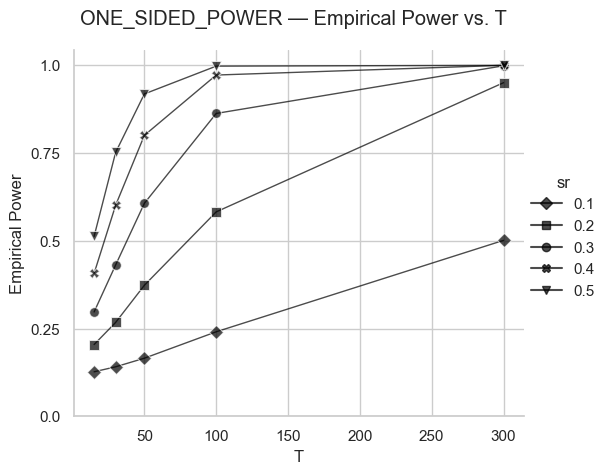

In [31]:
run_analysis(experiments, "fig7", alpha=0.05, plot_mask=[0,0,1], 
             line_plot_kargs=line_plot_kargs | {'yticks': [0.0, 0.25, 0.5, 0.75, 1.0]})

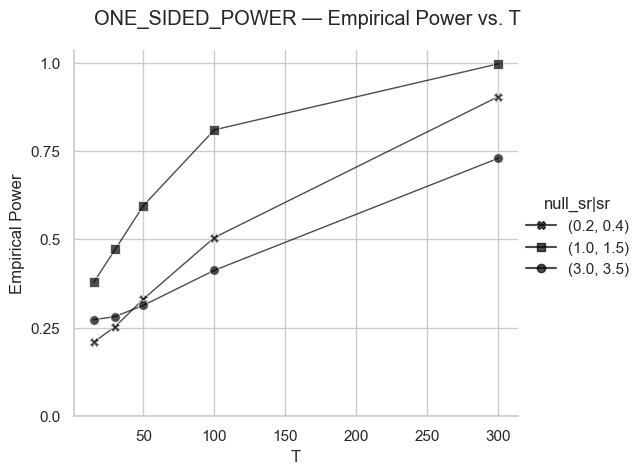

In [32]:
run_analysis(experiments, "fig8_a", alpha=0.05, plot_mask=[0,0,1], 
             line_plot_kargs=line_plot_kargs | dict(yticks= [0.0, 0.25, 0.5, 0.75, 1.0]) |
               dict(markers = ['X', 's', 'o']))

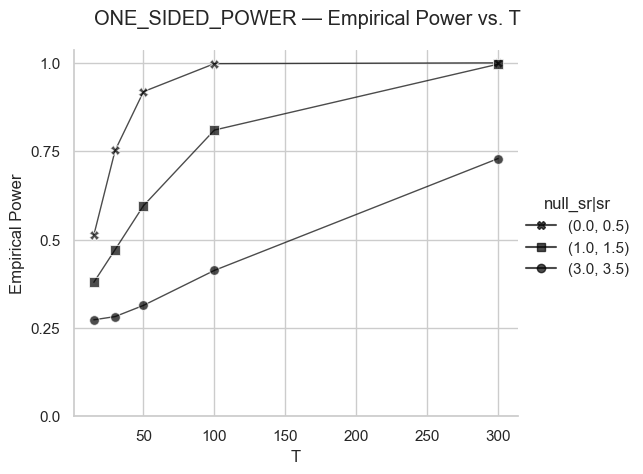

In [33]:
run_analysis(experiments, "fig8_b", alpha=0.05, plot_mask=[0,0,1], 
             line_plot_kargs=line_plot_kargs | dict(yticks= [0.0, 0.25, 0.5, 0.75, 1.0]) |
               dict(markers = ['X', 's', 'o']))